
# CT5146 Assignment 2 (Total 100 marks)




---
# **Task**

Please complete this task and **upload your answers to Canvas as a PDF ONLY with saved outputs**.  

📅 ***Deadline:*** **23:59** on **, November 21st 2025**  (Ireland Time)

⚠️ ***Late submissions*** will be penalised by **1% per day (For one week until November 27th 2025)**. Submission after this deadline will not be considered.


👤 This is an ***individual assignment*** and your work must be your own.  

**<font color="red">Strictly no Generative AI</font> : Do the assignment by yourself, write codes and answers fully in your own words without using AI tools.**  

<font color="red">**Note:** You must disable the AI features on Google Colab before working on this assignment.  
  
You can follow this video guide: [How to disable AI in Colab](https://youtu.be/qrGZv8nPh1o)</font>  


You may use libraries such as **Scikit-Learn** to complete this assignment.

⚠️ **Important:**  
- Make sure you fill in your **Name** and **Student ID** by running the below cell.  
- Do **not** modify any other cells in this notebook except those explicitly marked with  
  **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`**.  
- Ensure that all cells run successfully before submission.  
- We recommend using **Google Colab** to avoid any dependency issues.  



**Student Details**

In [ ]:
# Enter your details below
NAME = input("Student Name   : ")
STUDENT_ID = input("Student ID     : ")

# print(f"Student Name   : {NAME}")
# print(f"Student ID     : {STUDENT_ID}")

##  Data Explanation

In this assignment, you will build a **multi-label emotion detection** system for English texts.  
Each short text may express **zero, one, or multiple** emotions from the following fixed set:

> **Emotion labels:** `anger, fear, joy, sadness, surprise`



---

###  Dataset Structure

All files are located in the `./data/` directory.  
Each file is in **CSV format** with a header row. The columns differ slightly depending on whether the file includes labels.

| File | Columns | Description |
|------|----------|-------------|
| `train.csv` | `id,text,anger,fear,joy,sadness,surprise` | Training data.  |
| `dev.csv` | `id,text,anger,fear,joy,sadness,surprise` | validation data. |
| `test.csv` | `id,text` | Test data for which you will predict the six label columns. |

---

###  Example Row from `train.csv`


id,text,anger,fear,joy,sadness,surprise

eng_train_track_a_00001,"Colorado, middle of nowhere.",0,1,0,0,1,0

id → A unique identifier for the text sample (eng_train_track_a_00001).

text → The actual content to analyze ("Colorado, middle of nowhere.").

anger → 0 → the model (or annotators) determined anger is not present.

fear → 0 → no indication of fear.

joy → 0 → no joy detected.

sadness → 1 → sadness is expressed.

surprise → 0 → surprise is not expressed.




# Summary



In this assignment, you will build a **prompt-based emotion detection system** using a pretrained language model.  
The goal is to explore how different prompting strategies, from zero-shot to few-shot and beyond, affect performance on emotion classification.

You will complete the following tasks:
1. Load and Visualize the dataset.

2. Zero-Shot Prompting and Evaluation  
   - Load a small instruction-tuned model (e.g., `google/flan-t5-small`).  
   - Write a clear prompt that identifies which emotions appear in a given text.  
   - Apply your prompt to the development set and evaluate performance using **Precision**, **Recall**, and **Weighted F1-score**.  
   

3. Few-Shot Prompting and Evaluation
   - Extend your prompt by adding 3 to 5 labeled examples that illustrate how emotions are expressed.  
   - Reuse the same model and evaluation procedure.  
   - Compare results with the zero-shot version and interpret the improvements or remaining challenges.

4. Improvement and Evaluation
   - Implement one improvement of your choice to enhance emotion prediction.  
   - Evaluate the approach with the same metrics and summarize the effect of your changes.  
   



  




# Importing Libraries and Dataset


In [1]:
import os
import random
import warnings
import requests
from io import StringIO
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:

# Load the dataset

def download_file_from_google_drive(file_id):
    """
    Downloads a CSV file from Google Drive using its file_id
    and returns the content as text.
    """
    URL = "https://drive.google.com/uc?export=download&id=" + file_id
    response = requests.get(URL)
    response.raise_for_status()
    return response.text


file_id_train = "1Wx5AmKu2B4-yp-N7_j_toU_tv7UmI6qs"
file_id_dev   = "1ioGJH1xHXywX2xO3bxt-1hscAD6LoIwC"
file_id_test  = "1GdADQBIEbnKphMk64K98d3EPcGRofe3w"


# Read CSVs directly into pandas
train_df = pd.read_csv(StringIO(download_file_from_google_drive(file_id_train)))
dev_df   = pd.read_csv(StringIO(download_file_from_google_drive(file_id_dev)))
test_df  = pd.read_csv(StringIO(download_file_from_google_drive(file_id_test)))

# train_df = pd.read_csv('/content/train.csv')
# dev_df  = pd.read_csv('/content/validation.csv')
# test_df  = pd.read_csv('/content/test.csv')

# Print dataset shapes
print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)
EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]



Train shape: (2764, 7)
Dev shape: (115, 7)
Test shape: (2765, 7)


Take a look at the columns, and shape of the dataset.

In [3]:
train_df.head(10)

,id,text,anger,fear,joy,sadness,surprise
0,eng_train_track_a_00001,"Colorado, middle of nowhere.",0,1,0,0,1
1,eng_train_track_a_00002,This involved swimming a pretty large lake tha...,0,1,0,0,0
2,eng_train_track_a_00003,It was one of my most shameful experiences.,0,1,0,1,0
3,eng_train_track_a_00004,"After all, I had vegetables coming out my ears...",0,0,0,0,0
4,eng_train_track_a_00005,Then the screaming started.,0,1,0,1,1
5,eng_train_track_a_00006,"They don't fear death, and it seems they belie...",0,1,0,0,1
6,eng_train_track_a_00007,You know what happens when I get one of these ...,1,1,0,0,0
7,eng_train_track_a_00008,My stomach even started giving me fits.,0,1,0,1,0
8,eng_train_track_a_00009,"Well, as we're bowling, my dinner began to not...",0,1,0,0,0
9,eng_train_track_a_00010,Hondas are notoriously great cars for long tri...,0,0,1,0,0


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2764 entries, 0 to 2763
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        2764 non-null   object
 1   text      2764 non-null   object
 2   anger     2764 non-null   int64 
 3   fear      2764 non-null   int64 
 4   joy       2764 non-null   int64 
 5   sadness   2764 non-null   int64 
 6   surprise  2764 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 151.3+ KB


#Task 1. Data Exploration


### Data Visualization (10)
Plot a histogram illustrating the frequency of each emotion label in the training dataset.

In [ ]:
def data_exploration(train_df):
    """
    TODO:
    - Count how many times each emotion label appears in the training set.
    - Plot a bar chart of label frequencies (emotion on x-axis, count on y-axis).

    """
    # YOUR CODE HERE
    raise NotImplementedError()  # comment this line once you entered your code



#data_exploration(train_df)



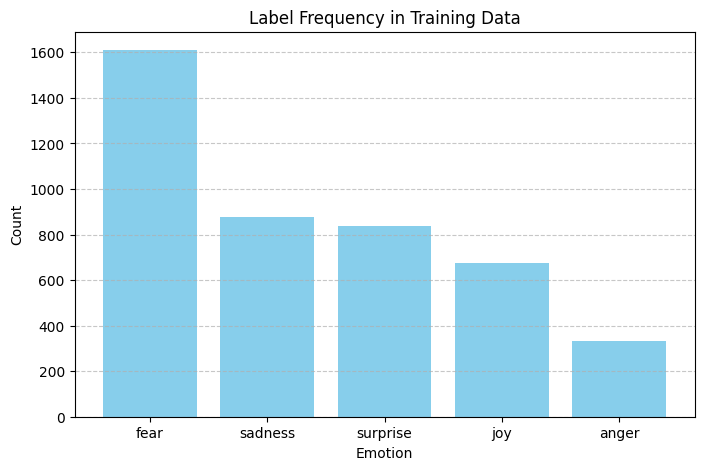

Label distribution:
fear        1610
sadness      876
surprise     839
joy          674
anger        333
dtype: int64


In [ ]:
data_exploration(train_df)

#Task 2. Zero shot prompting

### Task 2A. Zero-Shot Prompting and Evaluation (10 marks)

In this step, you will load a **small instruction-tuned language model** (e.g., `google/flan-t5-small` or any other pretrained model you find appropriate) and test whether it can follow a **basic emotion classification prompt**.

You will:
- Write a clear prompt that lists all five emotions (`anger`, `fear`, `joy`, `sadness`, `surprise`)  
  and asks the model to identify which ones are expressed in a short text.  
- Generate responses for a few example sentences to see how the model interprets your instructions.  
  
Compare a few prompt variations and determine which one performs best.

**Tip:** The exact phrasing of your prompt can make a big difference.  
Try different formats — e.g., *“Which of the following emotions apply?”* vs. *“Classify the emotions present (output only labels)”* —  
and observe how they affect accuracy.  
Your goal is to find the **most effective prompt** for emotion detection in a zero-shot setup.


In [ ]:


from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-small"  # or any other instruction-tuned model you find appropriate

print("Loading model:", MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

print("Model and tokenizer loaded successfully.")


In [ ]:

def test_zero_shot_prompt():
    """
    TODO:
    - Write a short prompt that asks the model which emotions appear in a given text.
    - Use the globally loaded model and tokenizer (do not reload them).
    - Generate the model's response for one sample text.
    - Print both the prompt and the model's response clearly.
    """
    # YOUR CODE HERE
    raise NotImplementedError()  # comment this line once you enter your code


# Example call
# test_zero_shot_prompt()


### Task 2B. Evaluate the Zero-Shot Methodology (10 marks)


- Implement a function that runs your zero-shot prompt on each text in the test set.  
- Compare the predicted emotions against the true labels.  
- Compute and report **Precision**, **Recall**, and **Weighted F1-score** across all five emotions.  




In [ ]:

from sklearn.metrics import classification_report
def evaluate_zero_shot():
    """
    TODO:
    - For each text in test_df:
        * Generate the model's response.
        * Convert the response into a binary prediction for each emotion (0 or 1).
    - Compare predictions with the true labels.
    - Compute Precision, Recall, and Weighted F1-score.
    return scores
    """
    # YOUR CODE HERE
    raise NotImplementedError()  # comment this line once you entered your code

# Example call
# evaluate_zero_shot()


### Task 2C. Interpretation Questions (10 marks)



1.  Which emotions were predicted most accurately, and which were the most difficult? Why do you think this happened?

2. How well did the model follow your prompt instructions? Provide one example where it worked well or failed.


Answer above questions briefly (less than 250 words).



# Task 3. Few Shot Prompting

### Task 3A. Few-Shot Model Setup (10 marks)

Extend your zero-shot system by adding **3–5 labeled examples** to the prompt before the query text.  
Use the same model and tokenizer already loaded earlier (Use the same model that you used for Task 1).  



In [ ]:


def test_few_shot_prompt():
    """
    TODO:
    - Reuse the already loaded model and tokenizer.
    - Create a prompt that includes 3–5 labeled examples, followed by a new query text.
    - Generate the model's output for one sample text.
    - Print the full prompt and the model's response.
    """
    # YOUR CODE HERE
    raise NotImplementedError()  # comment this line once you enter your code

# Example call
# test_few_shot_prompt()


### Section 3B — Evaluate the Few-Shot Methodology (10 marks)

Now apply your **few-shot prompt** to the test set and measure its performance.  
This step helps you understand whether providing a few labeled examples improves accuracy compared to zero-shot prompting.

You will:
- Apply your few-shot prompt to each text in the test set.  
- Convert the model's responses into binary emotion predictions.  
- Compute and report Precision, Recall and Weighted F1-score  across all five emotions.  
- Compare the results with your zero-shot evaluation.


In [ ]:


def evaluate_few_shot():
    """
    TODO:
    - For each text in test_df:
        * Build a few-shot prompt that includes the provided examples followed by the target text.
        * Generate the model's response using the loaded model and tokenizer.
        * Convert the response into binary predictions for each emotion (0 or 1).
    - Compare predictions with the true labels.
    - Compute and print macro Precision, Recall, and Weighted F1-score.

    """
    # YOUR CODE HERE
    raise NotImplementedError()  # comment this line once you enter your code

# Example call
# evaluate_few_shot()


### Section 3C — Interpretation Questions (10 marks)



1. How did the few-shot results differ from your zero-shot results? Which emotions benefited the most?

2. How did the chosen few-shot examples influence the model’s predictions? Provide one observation or example.

Answer above questions briefly (less than 250 words).




#Task 4. Implement An Improvement



###Task 4A — Classification Improvement (10 marks)

In this final task, you will implement an improvement to enhance the emotion classification system.  
You may build upon your previous zero-shot or few-shot approach, but the method should represent a meaningful extension or refinement.  
This is your opportunity to explore how prompting strategies or model interactions can lead to better results.

You should:

1. **Describe** your idea briefly in a Markdown cell (what you’re trying to improve and why).  
2. **Implement** your approach in code.  
  



In [ ]:


def implement_improvement():
    """
    TODO:
    - Apply your chosen improvement method to the existing system.
    - Generate predictions for the test set.

    """
    # YOUR CODE HERE
    raise NotImplementedError()  # comment this line once you enter your code

# Example call
# implement_improvement()


### Task 4B— Evaluation of Your Improved Method (10 marks)

Now evaluate your custom improvement using the same metrics as before, **Precision**, **Recall**, and **Weighted F1-score**.  
This helps determine whether your change led to measurable gains compared to your zero-shot and few-shot results.  



In [ ]:


def evaluate_few_shot():
    """
    TODO:
    - Compute evaluation metrics for your improved model:
        * Precision
        * Recall
        * Weighted F1-score
    - Print the results clearly for comparison with earlier methods.

    """
    # YOUR CODE HERE
    raise NotImplementedError()  # comment this line once you enter your code

# Example call
# evaluate_few_shot...


### Task 4C — Interpretation Questions (10 marks)



1. How did your modification affect the model’s performance compared to the few-shot and zero-shot results?

2.  Why do you think your improvement helped (or didn’t help)? Support your answer with examples or metric trends.

Answer above questions briefly (less than 250 words).



